In [1]:
# create a torch nn to compare the transformer to:
import torch
import numpy as np

In [ ]:
from dataset import Dataset,Track
np_rng = np.random.default_rng(42)
batch_size = 120
context_length = 32

# this code will only load the train sets if they are not already defined
# be cautious when changing parameters and re-runing this cell without restarting the jupyter kernel
try:
    print(type(train_set))
except:    
    train_set = Dataset("train", data_dir="../../data",context_length=context_length,uniform=True)
    validation_set = Dataset("val", data_dir="../../data", context_length=context_length, uniform=True)

def get_batch(set_name="train"):
        if set_name == "train":
            return train_set.get_batch_from_slices(batch_size, np_rng)
        if set_name == "val":
            return validation_set.get_batch_from_slices(batch_size, np_rng)

In [3]:
from torch import nn


class PureNnMidiClass(nn.Module):
    def __init__(self, context_length: int, num_classes: int, p_drop: float = 0.1):
        super().__init__()
        context_length_squred = context_length * context_length  # 32 * 32 = 1024
        self.components = nn.Sequential(
            nn.Dropout(p_drop),
            nn.Linear(context_length, context_length_squred),
            nn.Dropout(p_drop),
            nn.ReLU(),
            nn.Linear(context_length_squred, context_length_squred),
            nn.Dropout(p_drop),
            nn.ReLU(),
            nn.Linear(context_length_squred, context_length),
            nn.ReLU(),
            nn.Linear(context_length, num_classes),
        )

    def forward(self, x):
        logits = self.components.forward(x)
        return logits


model = PureNnMidiClass(context_length, 3).to(device="cuda")

In [6]:
optim = torch.optim.AdamW(model.parameters(),lr=1e-6) 
for iteration in range(100_000):
    batch= get_batch("train")
    x,y = batch
    x=torch.tensor(x,device="cuda",dtype=torch.float32)
    y=torch.tensor(y,device="cuda") 
    logits = model.forward(x)
    loss = nn.functional.cross_entropy(logits,y)
    model.zero_grad()
    loss.backward()
    optim.step()
    if iteration % 100 == 0:
        print(f"iteration: {iteration} and loss: {loss.item()}")




iteration: 0 and loss: 0.9749860167503357
iteration: 100 and loss: 0.9605168700218201
iteration: 200 and loss: 0.9811314344406128
iteration: 300 and loss: 0.9091932773590088
iteration: 400 and loss: 0.9435932040214539
iteration: 500 and loss: 0.976920485496521
iteration: 600 and loss: 1.0977132320404053
iteration: 700 and loss: 0.9561303853988647
iteration: 800 and loss: 0.9241431355476379
iteration: 900 and loss: 0.991584062576294
iteration: 1000 and loss: 0.9287888407707214
iteration: 1100 and loss: 1.0237549543380737
iteration: 1200 and loss: 0.9535677433013916
iteration: 1300 and loss: 1.084736704826355
iteration: 1400 and loss: 1.0397998094558716
iteration: 1500 and loss: 1.0050410032272339
iteration: 1600 and loss: 0.9885666966438293
iteration: 1700 and loss: 0.9834100604057312
iteration: 1800 and loss: 0.9629091024398804
iteration: 1900 and loss: 0.9557657241821289
iteration: 2000 and loss: 1.0332578420639038
iteration: 2100 and loss: 0.9475392699241638
iteration: 2200 and loss:

In [8]:
hits = 0
val_iters = 100
with torch.no_grad():
    for _ in range(val_iters):
        x, y = get_batch("val")
        x = torch.tensor(x,device="cuda",dtype=torch.float32)
        y = torch.tensor(y,device="cuda")
        logits = model.forward(x)
        model_preds = logits.argmax(-1)
        hits+=((model_preds==y).sum())
total_preds = val_iters * batch_size
print(hits/total_preds * 100)# give percentage

# ca 50% with context len 32 and 60% with 64

tensor(53.6333, device='cuda:0')


In [ ]:
# REDifine if you want to change the context_length for example
from dataset import Dataset,Track
np_rng = np.random.default_rng(42)
batch_size = 120
context_length = 32

# this code will only load the train sets if they are not already defined
# be cautious when changing parameters and re-runing this cell without restarting the jupyter kernel
try:
    print(type(train_set))
except:    
    train_set = Dataset("train", data_dir="../../data",context_length=context_length,uniform=True)
    validation_set = Dataset("val", data_dir="../../data", context_length=context_length, uniform=True)

def get_batch(set_name="train"):
        if set_name == "train":
            return train_set.get_batch_from_slices(batch_size, np_rng)
        if set_name == "val":
            return validation_set.get_batch_from_slices(batch_size, np_rng)

In [12]:
from torch import nn


class ConvNN(nn.Module):
    def __init__(self, context_length: int, num_classes: int, p_drop: float = 0.1):
        super().__init__()
        context_length_squred = context_length * context_length  # 32 * 32 = 1024

        self.components = nn.Sequential(
            nn.Dropout(p_drop),
            nn.Conv1d(1,32,5,1),
            nn.Dropout(p_drop),
            nn.Conv1d(32,64,5,1),
            nn.MaxPool1d(2,2),
            nn.Conv1d(64,128,3,1),
            nn.Conv1d(128,256,10),
            #  mat1 and mat2 shapes cannot be multiplied (30720x17 and 256x1024)
            nn.Flatten(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(1024, context_length),
            nn.ReLU(),
            nn.Linear(context_length, num_classes),
        )

    def forward(self, x):
        logits = self.components.forward(x)
        return logits


model = ConvNN(context_length, 3).to(device="cuda")

In [14]:
optim = torch.optim.AdamW(model.parameters(),lr=1e-6) 
for iteration in range(50_000):
    batch= get_batch("train")
    x,y = batch
    x=torch.tensor(x,device="cuda",dtype=torch.float32).reshape((batch_size,1,context_length))
    y=torch.tensor(y,device="cuda") 
    logits = model.forward(x)
    loss = nn.functional.cross_entropy(logits,y)
    model.zero_grad()
    loss.backward()
    optim.step()
    if iteration % 100 == 0:
        print(f"iteration: {iteration} and loss: {loss.item()}")




iteration: 0 and loss: 1.1124998331069946
iteration: 100 and loss: 1.1032565832138062
iteration: 200 and loss: 1.1203819513320923
iteration: 300 and loss: 1.1109379529953003
iteration: 400 and loss: 1.0862048864364624
iteration: 500 and loss: 1.1059411764144897
iteration: 600 and loss: 1.1019419431686401
iteration: 700 and loss: 1.0898081064224243
iteration: 800 and loss: 1.078744649887085
iteration: 900 and loss: 1.0539125204086304
iteration: 1000 and loss: 1.09396493434906
iteration: 1100 and loss: 1.103951334953308
iteration: 1200 and loss: 1.071082353591919
iteration: 1300 and loss: 1.0517863035202026
iteration: 1400 and loss: 1.0386393070220947
iteration: 1500 and loss: 1.0340945720672607
iteration: 1600 and loss: 1.0889678001403809
iteration: 1700 and loss: 1.0684895515441895
iteration: 1800 and loss: 1.0089868307113647
iteration: 1900 and loss: 1.0126256942749023
iteration: 2000 and loss: 1.0212002992630005
iteration: 2100 and loss: 0.9500494599342346
iteration: 2200 and loss: 1

In [ ]:
hits = 0
val_iters = 100
with torch.no_grad():
    for _ in range(val_iters):
        x, y = get_batch("val")
        x = torch.tensor(x,device="cuda",dtype=torch.float32).reshape((batch_size,1,context_length))
        y = torch.tensor(y,device="cuda")
        logits = model.forward(x)
        model_preds = logits.argmax(-1)
        hits+=((model_preds==y).sum())
total_preds = val_iters * batch_size
print(hits/total_preds * 100)# give percentage

# ca 60% with context len 32

tensor(60.3667, device='cuda:0')


In [20]:
x, y = get_batch("val")
print(x.shape)

(120, 32)


In [11]:
import matplotlib.pyplot as plt
import os
data_dir = "../../data"
name = "train"
only_genres = None # use all genres in the data folder
if not os.path.exists(os.path.join(data_dir, "tokenized", name)):
    raise FileNotFoundError(f"Dataset {name} not found")

_genres = os.listdir(os.path.join(data_dir, "tokenized", name))
genres = list()

for genre in _genres:
    if genre.startswith("GENRE_"):
        if only_genres is not None and genre[6:] not in only_genres:
            continue
        genres.append(genre[6:])

genres = sorted(genres)

_genres_to_idx = {}
for i, genre in enumerate(genres):
    _genres_to_idx[genre] = i

tracks = {}

for genre in genres:
    tracks[genre] = []
    for file in os.listdir(
        os.path.join(data_dir, "tokenized", name, f"GENRE_{genre}")
    ):
        if file.endswith(".bin"):
            track = Track(file[:-4], genre, name)
            if track.exists(data_dir=data_dir):
                tracks[genre].append(track)
            else:
                print(f"File {file} not found")
                #raise FileNotFoundError(f"Tokenized file {file} not found")
        


In [15]:
total_token_distribution= {}
tokens_per_class = {}
for genre in genres:
    total_token_distribution[genre]=np.zeros((483,))
    tokens_per_class[genre]=0
    for track in tracks[genre]:
        track = track.get_memmap(data_dir=data_dir)
        np.add.at(total_token_distribution[genre],track,1)
        tokens_per_class[genre]+=track.shape[0]

{'classical': 29026221, 'pop': 63285502, 'rock': 79744441}


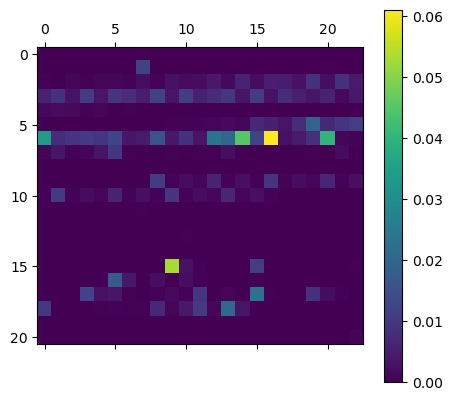

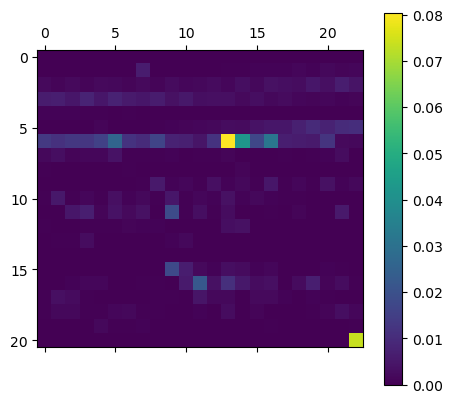

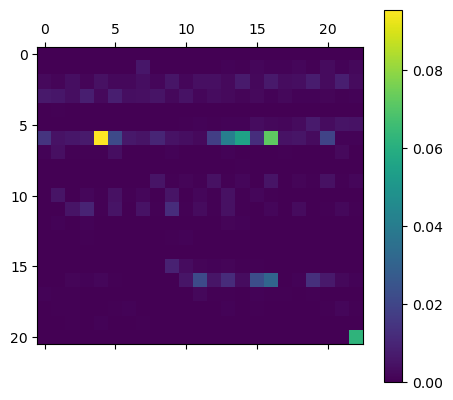

In [29]:
print(tokens_per_class)
#print(total_token_distribution)

all_genres_matrix = np.stack([distri.reshape((21,23))/tokens_per_class[genre] for genre,distri in total_token_distribution.items()])
for index in range(all_genres_matrix.shape[0]):
    plt.matshow(all_genres_matrix[index])
    plt.colorbar()
    